<a href="https://colab.research.google.com/github/gracella12/PP_Assignment/blob/main/PP_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 02 : Feature Extraction
Nama: Gracella Wiendy Koesnadi

NIM : 24/541739/PA/22991


---



Implementasikan histogram of energy, histogram of zero crossing rate, histogram of energy entropy tanpa menggunakan library. Yang perlu anda submit adalah link google colab.

In [1]:
pip install gdown librosa

In [37]:
import librosa
from scipy.signal import butter, filtfilt
import numpy as np
import os
import matplotlib.pyplot as plt
import librosa.display
import IPython.display as ipd
import gdown
import glob
import pandas as pd
import seaborn as sns

# Reading Audio File

In [18]:
audio_p_path = "/content/audio perempuan.wav"
audio_l_path = "/content/audio laki.wav"

In [20]:
audio_p = ipd.Audio(audio_p_path)
audio_p

In [19]:
y, sr = librosa.load(audio_p_path) #y = raw data, sr = sample rate

In [14]:
print(y)
print (sr)
print(y.shape)

[ 9.5568885e-06  7.9793908e-06 -2.6755220e-06 ...  5.4625878e-07
 -1.0571671e-07 -2.2206166e-07]
22050
(83138,)


<Axes: >

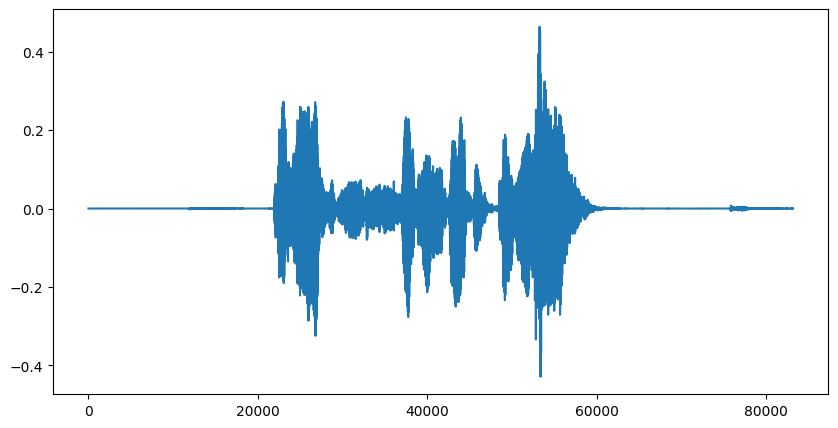

In [17]:
# convert into series
pd.Series(y).plot(figsize=(10,5))

#Audio Preprocessing

In [22]:
#resampling to 16 KHz
y, sr = librosa.load(audio_p_path, sr=16000)
print(sr)

16000


In [24]:
#Filtering
def butter_lowpass_filter(data, cutoff_freq, sample_rate, order=4):
    nyquist = 0.5 * sample_rate
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_data = filtfilt(b, a, data)
    print(f"Filtered audio shape: {filtered_data.shape}")
    return filtered_data

filtered_audio = butter_lowpass_filter(y, cutoff_freq=4000, sample_rate=sr)

Filtered audio shape: (60327,)


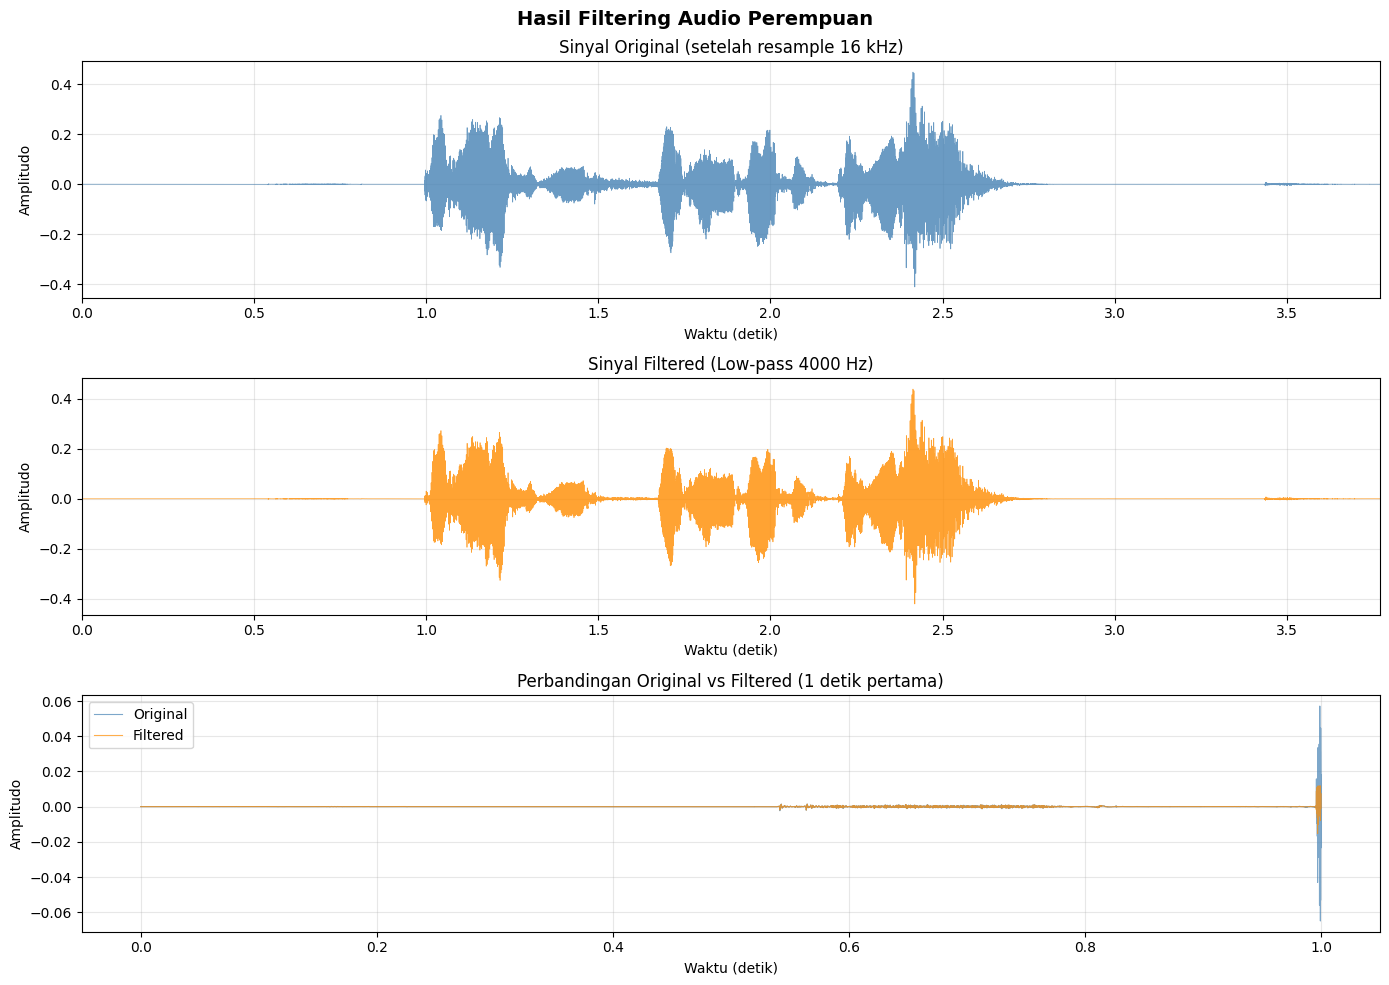

In [26]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Hasil Filtering Audio Perempuan', fontsize=14, fontweight='bold')

# Buat array waktu
time_original = np.linspace(0, len(y) / sr, len(y))
time_filtered = np.linspace(0, len(filtered_audio) / sr, len(filtered_audio))

# Plot 1: Sinyal Original
axes[0].plot(time_original, y, color='steelblue', linewidth=0.5, alpha=0.8)
axes[0].set_title('Sinyal Original (setelah resample 16 kHz)')
axes[0].set_xlabel('Waktu (detik)')
axes[0].set_ylabel('Amplitudo')
axes[0].set_xlim([0, time_original[-1]])
axes[0].grid(True, alpha=0.3)

# Plot 2: Sinyal Filtered
axes[1].plot(time_filtered, filtered_audio, color='darkorange', linewidth=0.5, alpha=0.8)
axes[1].set_title('Sinyal Filtered (Low-pass 4000 Hz)')
axes[1].set_xlabel('Waktu (detik)')
axes[1].set_ylabel('Amplitudo')
axes[1].set_xlim([0, time_filtered[-1]])
axes[1].grid(True, alpha=0.3)

# Plot 3: Overlay perbandingan (zoom 1 detik pertama)
zoom_samples = sr  # 1 detik
axes[2].plot(time_original[:zoom_samples], y[:zoom_samples],
             color='steelblue', linewidth=0.8, alpha=0.7, label='Original')
axes[2].plot(time_filtered[:zoom_samples], filtered_audio[:zoom_samples],
             color='darkorange', linewidth=0.8, alpha=0.7, label='Filtered')
axes[2].set_title('Perbandingan Original vs Filtered (1 detik pertama)')
axes[2].set_xlabel('Waktu (detik)')
axes[2].set_ylabel('Amplitudo')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Windowing

In [29]:
import numpy as np

frame_size = int(0.025 * sr) # ambil x sample per frame
overlap = int(0.010 * sr)    # geser x sample

total_frame = 1 + (len(filtered_audio) - frame_size) // overlap

frames = []

for i in range(total_frame):
  start = i * overlap
  end = start + frame_size
  current_frame = filtered_audio[start:end]

  # 3. Masukkan potongan tersebut ke list utama
  frames.append(current_frame)

# Konversi list of arrays menjadi 2D NumPy Array
frames = np.array(frames)

hamming_window = np.hamming(frame_size)   # bentuk: (frame_size,)
frames_windowed = frames * hamming_window # broadcast otomatis

print(f"Frame size  : {frame_size} sampel ({frame_size/sr*1000:.0f}ms)")
print(f"Hop size    : {overlap} sampel ({overlap/sr*1000:.0f}ms)")
print(f"Jumlah frame: {total_frame}")
print(f"Shape frames: {frames_windowed.shape}")

Frame size  : 400 sampel (25ms)
Hop size    : 160 sampel (10ms)
Jumlah frame: 375
Shape frames: (375, 400)


# Extract Feature

##Audio Energy

In [ ]:
audio_energy = []

for i in range(total_frame):
    sum_kuadrat = 0                        # reset tiap frame baru

    for j in range(frame_size):            # loop tiap sampel dalam frame
        amplitudo_kuadrat = frames_windowed[i][j] ** 2 #akses tiap titik dalam window
        sum_kuadrat += amplitudo_kuadrat

    energy = (1 / frame_size) * sum_kuadrat
    audio_energy.append(energy)

audio_energy = np.array(audio_energy)
print(audio_energy)

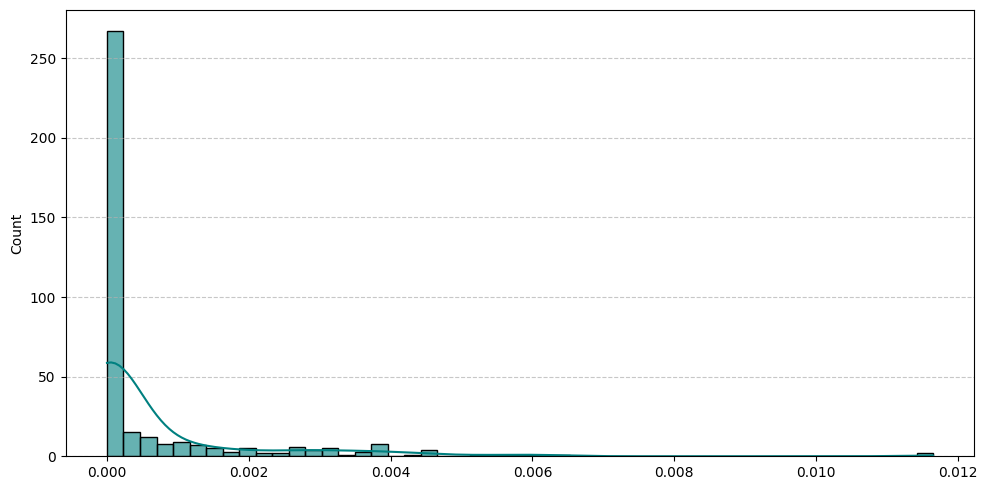

In [41]:
plt.figure(figsize=(10, 5))
sns.histplot(audio_energy, bins=50, kde=True, color="teal", alpha=0.6)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Zero Crossing Rate (ZCR)

In [43]:
zcr_list = []

for i in range(total_frame):
    sum_zcr = 0
    for j in range(1, frame_size):        # mulai dari 1 karena butuh j-1
        if frames_windowed[i][j] * frames_windowed[i][j-1] < 0:
            sum_zcr += 1                  # terjadi pergantian tanda

    zcr = (1 / (2 * frame_size)) * sum_zcr
    zcr_list.append(zcr)

zcr_list = np.array(zcr_list)
print(zcr_list)

[0.19    0.17625 0.17    0.155   0.13125 0.125   0.13625 0.1525  0.1425
 0.15875 0.14125 0.15375 0.1575  0.16625 0.1125  0.09875 0.13125 0.15625
 0.12875 0.1275  0.14375 0.15125 0.145   0.17    0.18625 0.21625 0.225
 0.2075  0.215   0.2075  0.2075  0.1925  0.195   0.18    0.18625 0.1825
 0.13875 0.10625 0.13    0.18625 0.205   0.20625 0.19375 0.185   0.1775
 0.18625 0.195   0.21    0.2075  0.19375 0.175   0.1875  0.14625 0.09625
 0.0675  0.06875 0.075   0.09375 0.11875 0.12375 0.12375 0.1175  0.11375
 0.12125 0.1275  0.1225  0.11625 0.125   0.11875 0.1175  0.11875 0.12
 0.1175  0.1125  0.1125  0.11875 0.12    0.1175  0.095   0.07125 0.03875
 0.05125 0.0925  0.13625 0.1425  0.13875 0.14125 0.15125 0.155   0.14125
 0.1475  0.115   0.095   0.07    0.0725  0.05875 0.0625  0.06125 0.08625
 0.09    0.06375 0.02625 0.02625 0.03625 0.05    0.0475  0.04625 0.0475
 0.0525  0.06    0.06    0.0625  0.06125 0.06375 0.06375 0.06375 0.075
 0.07875 0.08875 0.095   0.10125 0.10125 0.08625 0.06625 0.052

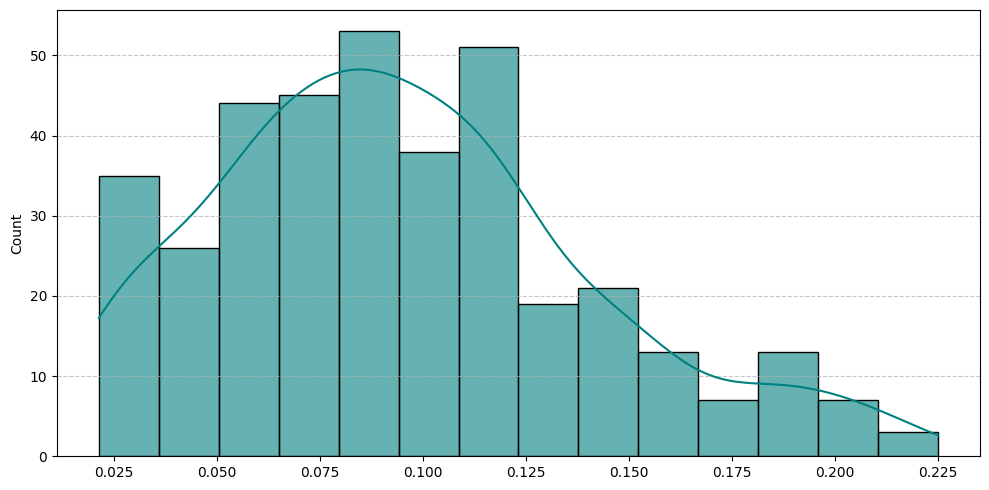

In [44]:
plt.figure(figsize=(10, 5))
sns.histplot(zcr_list, kde=True, color="teal", alpha=0.6)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##Entropy of Energy

In [45]:
sub_frame_size = 200
overlap        = 100
entropy_list   = []

for i in range(total_frame):

    # bagi tiap frame jadi sub-frame
    total_sub_frame = 1 + (len(frames_windowed[i]) - sub_frame_size) // overlap
    sub_frames = []
    for j in range(total_sub_frame):
        start = j * overlap
        end   = start + sub_frame_size
        sub_frames.append(frames_windowed[i][start:end])

    sub_frames = np.array(sub_frames)                 # konversi dulu sebelum dikali

    #terapin hamming window ke subframe
    hamming_window     = np.hamming(sub_frame_size)
    sub_frames_windowed = sub_frames * hamming_window

    # hitung energy tiap subframe
    sub_energy = []
    for k in range(total_sub_frame):
        sum_kuadrat = 0
        for l in range(sub_frame_size):
            sum_kuadrat += sub_frames_windowed[k][l] ** 2  # bukan frames_windowed
        sub_energy.append((1 / sub_frame_size) * sum_kuadrat)

    sub_energy = np.array(sub_energy)

    #energy normalization
    total_energy = np.sum(sub_energy)
    if total_energy == 0:
        entropy_list.append(0)
        continue

    norm = sub_energy / total_energy                  # hasil: array probabilitas

    # hitung entropy
    entropy = -1 * np.sum(norm * np.log2(norm + 1e-10))
    entropy_list.append(entropy)                      # append per frame

entropy_list = np.array(entropy_list)
print(entropy_list)

[8.59041900e-01 4.44092923e-01 7.16195304e-01 1.39656045e+00
 1.58005371e+00 1.47928478e+00 1.50386424e+00 8.57504025e-01
 1.41417842e+00 1.43185201e+00 1.34590478e+00 1.16975361e+00
 1.53728749e+00 1.22212364e+00 1.29766830e+00 1.18795858e+00
 9.33221400e-01 1.22204047e+00 1.06949871e+00 9.99602622e-01
 1.14398093e+00 9.90471660e-01 7.01423671e-01 8.03343116e-01
 3.92279070e-01 1.31480430e+00 1.38534747e+00 1.12534837e+00
 1.11543954e+00 6.34304379e-01 6.81251608e-01 9.38902576e-01
 9.26997016e-01 9.68686264e-01 8.88634268e-01 9.72055739e-01
 1.42622589e-06 1.90618641e-09 9.44881996e-01 7.37642537e-01
 7.10698162e-01 7.92246477e-01 9.90441696e-01 7.59381708e-01
 6.41150819e-01 7.19115330e-01 1.11529693e+00 9.35282406e-01
 1.58208848e+00 1.15397631e+00 1.51095829e+00 1.18419081e+00
 1.59193874e-01 3.34333402e-01 1.50859843e+00 9.45773293e-01
 1.41033287e+00 1.51734259e+00 1.07711755e+00 1.45827439e+00
 1.28274169e+00 1.11297563e+00 1.04934356e+00 1.30399957e+00
 1.42181682e+00 1.581031

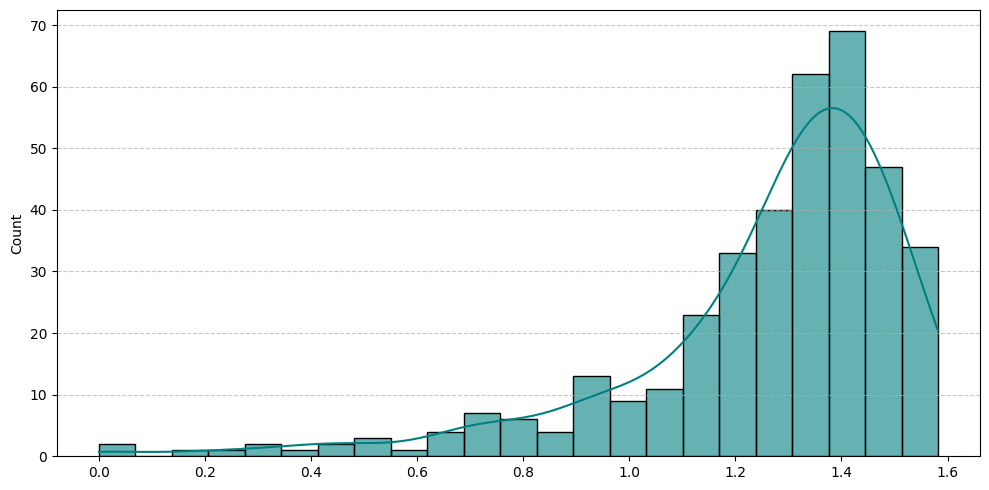

In [47]:
plt.figure(figsize=(10, 5))
sns.histplot(entropy_list, kde=True, color="teal", alpha=0.6)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()